In [ ]:
# NOTE: use FastLloyd/env.yml
import sys, os
from pathlib import Path

def _find_project_root():
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / ".git").exists():
            return parent
    raise RuntimeError("Could not find project root (.git not found)")

root = str(_find_project_root())
os.chdir(root)
if root not in sys.path:
    sys.path.insert(0, root)

In [ ]:
from src.helpers import *
import numpy as np
datasets, k_dict, r_dict, l_inf_dict = get_grid_datasets_final()

In [2]:
# File paths — our methods
PE_FOLDER     = 'result_final/ours_final_may14'
HDPE_FOLDER   = 'result_final/ours_dim_reduced_may14'

# File paths — baselines
GOOGLE_FOLDER      = 'result_final/google_baseline_50'
FASTLLOYD_FOLDER   = 'result_final/fastlloyd_baseline_50'
DIFFPRIVLIB_FOLDER = 'result_final/diffprivlib_baseline_50'
ICML_FOLDER        = 'result_final/icml_baseline_50_jun24'

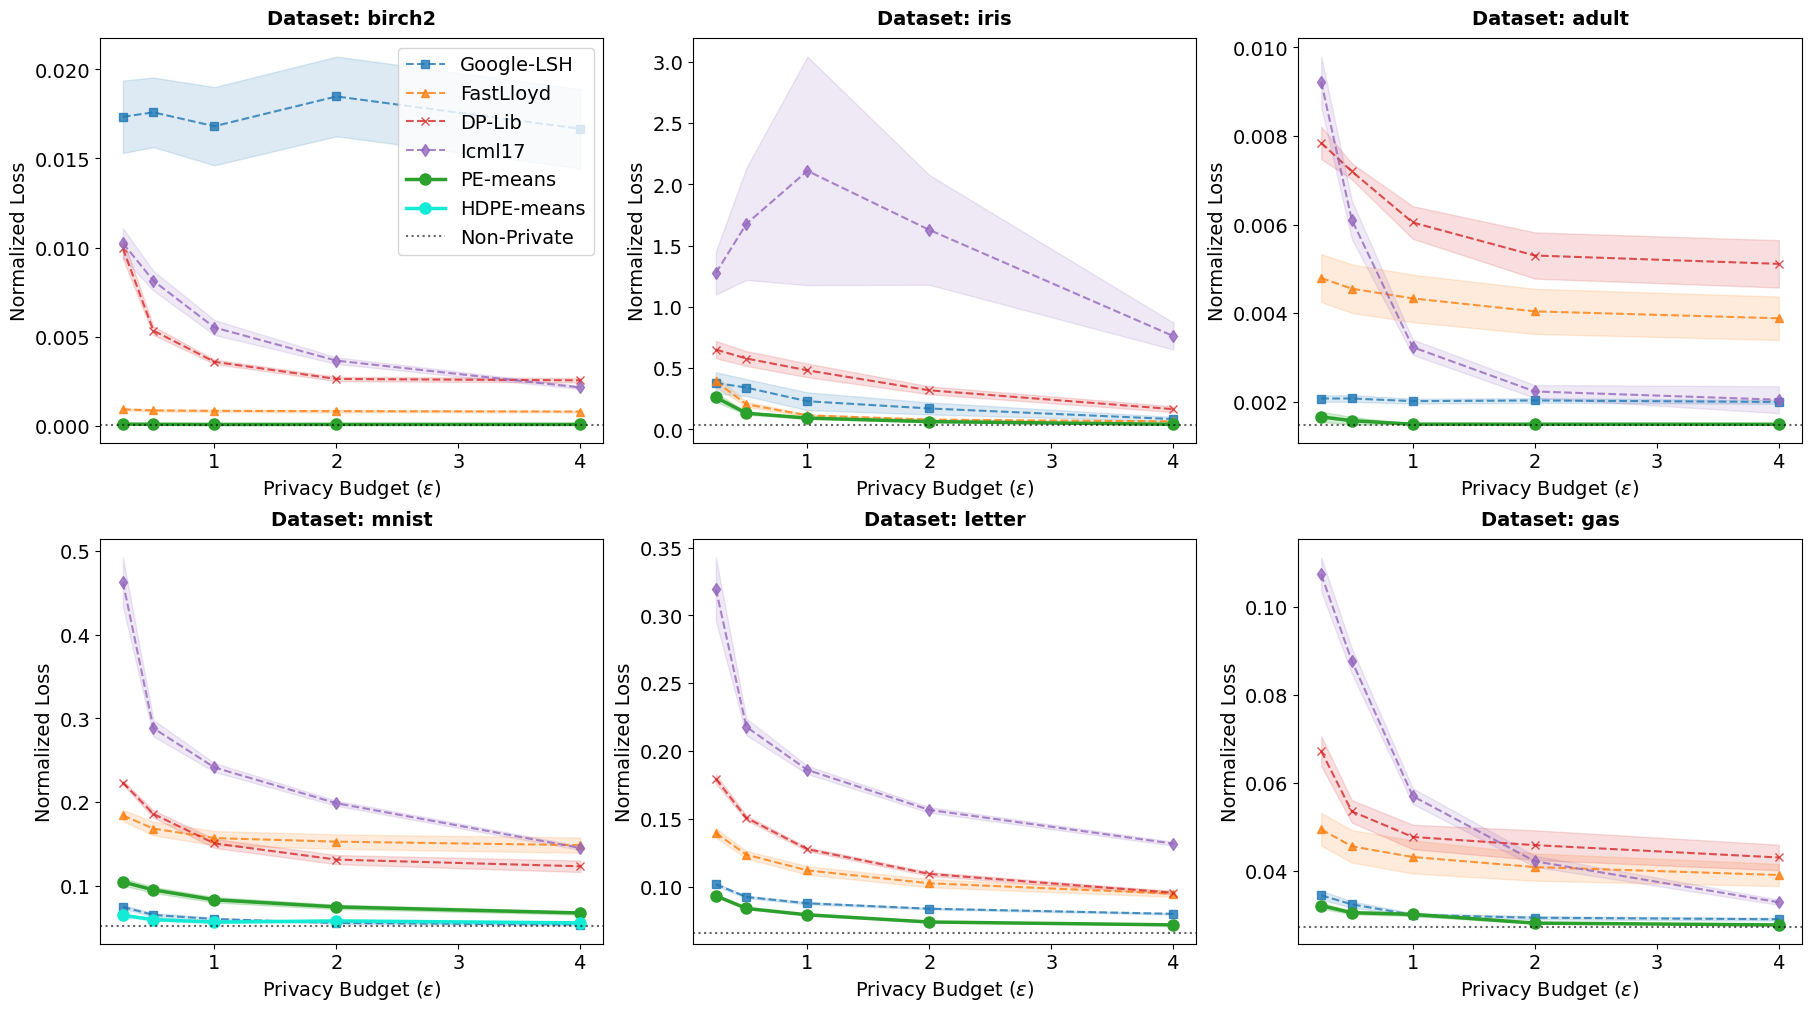

In [3]:
import matplotlib.pyplot as plt
import scipy.stats
import numpy as np
import pickle
from collections import defaultdict
import matplotlib as mpl
from matplotlib.lines import Line2D
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

#https://stackoverflow.com/questions/15033511/compute-a-confidence-interval-from-sample-data
def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    if n < 2:  # Cannot compute CI with less than 2 points
        return np.mean(a), np.mean(a), np.mean(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n - 1)
    return m, m - h, m + h

# --- REFACTORED DATA HELPER ---
def get_loss_stats(path, dataset_size, eps):
    try:
        with open(path, 'rb') as f:
            data = pickle.load(f)
            # Normalize the entire list of losses by dataset size
            raw_losses = np.array(data['loss'][str(eps)]) / dataset_size
            return mean_confidence_interval(raw_losses)
    except:
        return np.nan, np.nan, np.nan

# --- PLOTTING CONFIGURATION ---
SELECTED_DATASETS = list(datasets.keys())[:6]
n_cols = 3
n_rows = (len(SELECTED_DATASETS) + n_cols - 1) // n_cols
plt.rcParams.update({
    'font.size': 14,           # base font size
    'axes.titlesize': 14,      # axes title
    'axes.labelsize': 14,      # x/y axis labels
    'xtick.labelsize': 14,     # x tick labels
    'ytick.labelsize': 14,     # y tick labels
    'legend.fontsize': 14,     # legend text
    'figure.titlesize': 14,    # figure suptitle
})
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), constrained_layout=True)
axes = axes.flatten()

styles = {
    'PE': {'color': '#2ca02c', 'marker': 'o', 'linewidth': 2.5, 'markersize': 8},
    'HDPE' : {'color': "#13ebd6", 'marker': 'o', 'linewidth': 2.5, 'markersize': 8},
    'Google-LSH': {'color': '#1f77b4', 'marker': 's', 'linestyle': '--', 'alpha': 0.8},
    'FastLloyd': {'color': '#ff7f0e', 'marker': '^', 'linestyle': '--', 'alpha': 0.8},
    'DP-Lib': {'color': '#d62728', 'marker': 'x', 'linestyle': '--', 'alpha': 0.8},
    'Icml17': {'color': '#9467bd', 'marker': 'd', 'linestyle': '--', 'alpha': 0.8}
}

for i, dataset_name in enumerate(SELECTED_DATASETS):
    ax = axes[i]
    dataset = datasets[dataset_name]
    size = dataset.shape[0]
    
    # 1. Plot Private Baselines with CI
    for algo in ['Google-LSH', 'FastLloyd', 'DP-Lib', 'Icml17']:
        path = {
            'Google-LSH': f'{GOOGLE_FOLDER}/baseline_{dataset_name}.pkl',
            'FastLloyd':  f'{FASTLLOYD_FOLDER}/fastlloyd_{dataset_name}.pkl',
            'DP-Lib':     f'{DIFFPRIVLIB_FOLDER}/diffpriv_{dataset_name}.pkl',
            'Icml17':     f'{ICML_FOLDER}/baseline_{dataset_name}.pkl',
        }[algo]
        
        # Collect stats for every epsilon
        stats = [get_loss_stats(path, size, e) for e in EPSILONS]
        m_vals, lb_vals, ub_vals = zip(*stats)
        
        # Plot line and shaded CI
        ax.plot(EPSILONS, m_vals, label=algo, **styles[algo])
        ax.fill_between(EPSILONS, lb_vals, ub_vals, color=styles[algo]['color'], alpha=0.15)

    # 2. Plot PE (Our Method) with CI
    try:
        with open(f'{PE_FOLDER}/grid_results_{dataset_name}.pkl', 'rb') as f:
            list_tuples = pickle.load(f)
        pe_lookup = defaultdict(list)
        for config, loss, centers, convergence in list_tuples:
            pe_lookup[config['eps']].append(convergence[-1])
        
        pe_stats = []
        for e in EPSILONS:
            if e in pe_lookup:
                # Normalize by size before calculating CI
                pe_raw = np.array(pe_lookup[e]) / size
                pe_stats.append(mean_confidence_interval(pe_raw))
            else:
                pe_stats.append((np.nan, np.nan, np.nan))
        
        m_pe, lb_pe, ub_pe = zip(*pe_stats)
        ax.plot(EPSILONS, m_pe, label='PE-means', **styles['PE'])
        ax.fill_between(EPSILONS, lb_pe, ub_pe, color=styles['PE']['color'], alpha=0.2)
    except:
        pass

    # 3. Plot HDPE
    if dataset.shape[1] > 32:
        try:
            with open(f'{HDPE_FOLDER}/grid_results_{dataset_name}.pkl', 'rb') as f:
                list_tuples = pickle.load(f)
            hdpe_lookup = defaultdict(list)
            for config, loss, centers, convergence in list_tuples:
                hdpe_lookup[config['eps']].append(loss)
            
            pe_stats = []
            for e in EPSILONS:
                if e in hdpe_lookup:
                    # Normalize by size before calculating CI
                    pe_raw = np.array(hdpe_lookup[e]) / size
                    pe_stats.append(mean_confidence_interval(pe_raw))
                else:
                    pe_stats.append((np.nan, np.nan, np.nan))
            
            m_pe, lb_pe, ub_pe = zip(*pe_stats)
            ax.plot(EPSILONS, m_pe, label='HDPE-means', **styles['HDPE'])
            ax.fill_between(EPSILONS, lb_pe, ub_pe, color=styles['HDPE']['color'], alpha=0.2)
        except:
            pass

    # 4. Reference Line: Non-Private
    non_private_val, _, _ = get_loss_stats(f'{GOOGLE_FOLDER}/baseline_{dataset_name}.pkl', size, 'inf')
    if not np.isnan(non_private_val):
        ax.axhline(y=non_private_val, color='black', linestyle=':', label='Non-Private', alpha=0.6)

    # Formatting
    ax.set_title(f"Dataset: {dataset_name}", fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel(r"Privacy Budget ($\epsilon$)")
    ax.set_ylabel("Normalized Loss")
    ax.grid(False)

# Add legend to ax 0 with proxy artists covering all possible line types
legend_entries = [
    Line2D([0], [0], label='Google-LSH', **styles['Google-LSH']),
    Line2D([0], [0], label='FastLloyd', **styles['FastLloyd']),
    Line2D([0], [0], label='DP-Lib', **styles['DP-Lib']),
    Line2D([0], [0], label='Icml17', **styles['Icml17']),
    Line2D([0], [0], label='PE-means', **styles['PE']),
    Line2D([0], [0], label='HDPE-means', **styles['HDPE']),
    Line2D([0], [0], color='black', linestyle=':', label='Non-Private', alpha=0.6),
]
axes[0].legend(handles=legend_entries, loc='upper right', frameon=True)

# Cleanup and Labels
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.savefig(
    'plots/real_datasets.pdf', 
    format='pdf', 
    bbox_inches='tight', 
    transparent=False
)
plt.show()
# Close the plot to free up memory
plt.close()

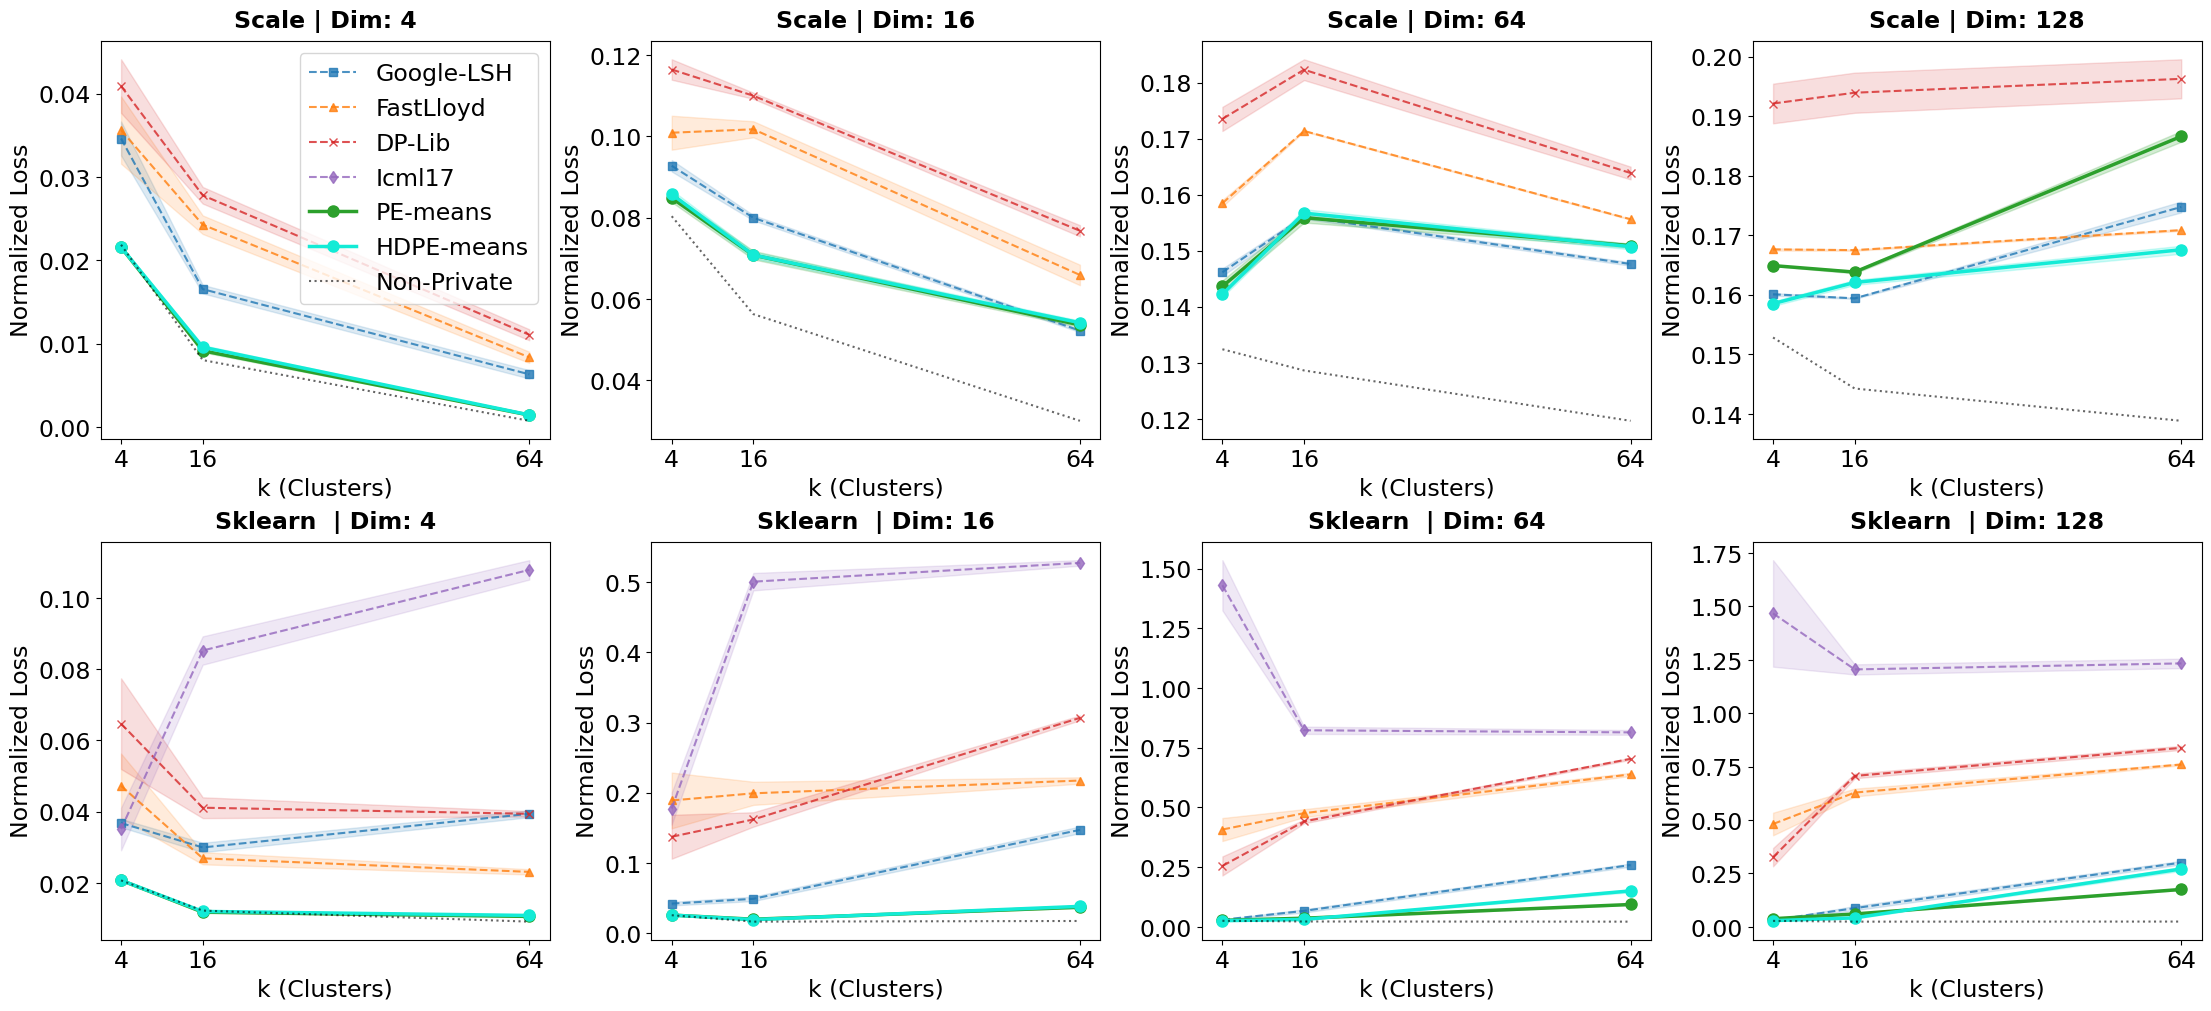

In [7]:
import matplotlib.pyplot as plt
import scipy.stats
import numpy as np
import pickle
from collections import defaultdict
import matplotlib as mpl
from matplotlib.lines import Line2D
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
# --- CONFIGURATION ---
DATASET_STRINGS = [
    'scale_4_4', 'scale_4_16', 'scale_4_64', 'scale_4_128', 
    'scale_16_4', 'scale_16_16', 'scale_16_64', 'scale_16_128', 
    'scale_64_4', 'scale_64_16', 'scale_64_64', 'scale_64_128', 
    'sklearn_synthetic_4_4', 'sklearn_synthetic_16_4', 'sklearn_synthetic_64_4', 
    'sklearn_synthetic_4_16', 'sklearn_synthetic_16_16', 'sklearn_synthetic_64_16', 
    'sklearn_synthetic_4_64', 'sklearn_synthetic_16_64', 'sklearn_synthetic_64_64', 
    'sklearn_synthetic_4_128', 'sklearn_synthetic_16_128', 'sklearn_synthetic_64_128'
]

FIXED_EPS = 1.0
PLOT_ALGO_LIST = ['Google-LSH', 'FastLloyd', 'DP-Lib', 'Icml17']

# 1. Group and Sort Data
# Key: (name, int(dim)), Value: list of (k_val, full_string)
groups = defaultdict(list)
for s in DATASET_STRINGS:
    parts = s.split('_')
    dim_val = int(parts[-1])
    k_val = int(parts[-2])
    name = "_".join(parts[:-2])
    groups[(name, dim_val)].append((k_val, s))

# Sort keys: First by name (to keep rows consistent), then by dimension (smallest to largest)
sorted_group_keys = sorted(groups.keys(), key=lambda x: (x[0], x[1]))
plt.rcParams.update({
    'font.size': 17,           # base font size
    'axes.titlesize': 17,      # axes title
    'axes.labelsize': 17,      # x/y axis labels
    'xtick.labelsize': 17,     # x tick labels
    'ytick.labelsize': 17,     # y tick labels
    'legend.fontsize': 17,     # legend text
    'figure.titlesize': 17,    # figure suptitle
})
# 2. Setup 4x2 Subplots
fig, axes = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True)
axes = axes.flatten()

# Consistency styles
styles = {
    'PE': {'color': '#2ca02c', 'marker': 'o', 'linewidth': 2.5, 'markersize': 8},
    'HDPE' : {'color': "#13ebd6", 'marker': 'o', 'linewidth': 2.5, 'markersize': 8},
    'Google-LSH': {'color': '#1f77b4', 'marker': 's', 'linestyle': '--', 'alpha': 0.8},
    'FastLloyd': {'color': '#ff7f0e', 'marker': '^', 'linestyle': '--', 'alpha': 0.8},
    'DP-Lib': {'color': '#d62728', 'marker': 'x', 'linestyle': '--', 'alpha': 0.8},
    'Icml17': {'color': '#9467bd', 'marker': 'd', 'linestyle': '--', 'alpha': 0.8}
}

# 3. Plotting Loop
for i, (name, dim) in enumerate(sorted_group_keys):
    if i >= 8: break  # Limit to 4x2
    ax = axes[i]
    
    # Get sorted k list for this subplot
    current_group = sorted(groups[(name, dim)])
    k_list = [item[0] for item in current_group]
    str_list = [item[1] for item in current_group]
    
    # --- Plot Private Baselines ---
    for algo in PLOT_ALGO_LIST:
        if name == 'scale' and algo == 'Icml17':
            continue  # Skip Icml17 for scale datasets due to large loss
        m_list, lb_list, ub_list = [], [], []
        for d_str in str_list:
            size = datasets[d_str].shape[0]
            path = {
                'Google-LSH': f'{GOOGLE_FOLDER}/baseline_{d_str}.pkl',
                'FastLloyd':  f'{FASTLLOYD_FOLDER}/fastlloyd_{d_str}.pkl',
                'DP-Lib':     f'{DIFFPRIVLIB_FOLDER}/diffpriv_{d_str}.pkl',
                'Icml17':     f'{ICML_FOLDER}/baseline_{d_str}.pkl',
            }[algo]
            m, lb, ub = get_loss_stats(path, size, FIXED_EPS)
            m_list.append(m); lb_list.append(lb); ub_list.append(ub)
        
        ax.plot(k_list, m_list, label=algo, **styles[algo])
        ax.fill_between(k_list, lb_list, ub_list, color=styles[algo]['color'], alpha=0.15)

    # --- Plot PE (Our Method) ---
    pe_m, pe_lb, pe_ub = [], [], []
    for d_str in str_list:
        try:
            size = datasets[d_str].shape[0]
            with open(f'{PE_FOLDER}/grid_results_{d_str}.pkl', 'rb') as f:
                list_tuples = pickle.load(f)
            
            # Using raw float key matching as established in previous logic
            final_losses = [tup[3][-1] for tup in list_tuples if tup[0]['eps'] == FIXED_EPS]
            m, lb, ub = mean_confidence_interval(np.array(final_losses) / size)
            pe_m.append(m); pe_lb.append(lb); pe_ub.append(ub)
        except:
            pe_m.append(np.nan); pe_lb.append(np.nan); pe_ub.append(np.nan)
            
    ax.plot(k_list, pe_m, label='PE-means', **styles['PE'])
    ax.fill_between(k_list, pe_lb, pe_ub, color=styles['PE']['color'], alpha=0.2)
    
    # --- Plot HDPE (Our Method) ---
    hdpe_m, hdpe_lb, hdpe_ub = [], [], []
    for d_str in str_list:
        try:
            size = datasets[d_str].shape[0]
            with open(f'{HDPE_FOLDER}/grid_results_{d_str}.pkl', 'rb') as f:
                list_tuples = pickle.load(f)
            
            # Using raw float key matching as established in previous logic
            final_losses = [tup[1] for tup in list_tuples if tup[0]['eps'] == FIXED_EPS]
            m, lb, ub = mean_confidence_interval(np.array(final_losses) / size)
            hdpe_m.append(m); hdpe_lb.append(lb); hdpe_ub.append(ub)
        except:
            hdpe_m.append(np.nan); hdpe_lb.append(np.nan); hdpe_ub.append(np.nan)
            
    ax.plot(k_list, hdpe_m, label='HDPE-means', **styles['HDPE'])
    ax.fill_between(k_list, hdpe_lb, hdpe_ub, color=styles['HDPE']['color'], alpha=0.2)

    # --- Plot Non-Private Baseline (Dotted Curve) ---
    np_list = [get_loss_stats(f'{GOOGLE_FOLDER}/baseline_{d_str}.pkl', datasets[d_str].shape[0], 'inf')[0] for d_str in str_list]
    ax.plot(k_list, np_list, color='black', linestyle=':', label='Non-Private', alpha=0.6)

    # --- Formatting ---
    title_name = name.replace('synthetic','').replace('_', ' ').title()
    ax.set_title(f"{title_name} | Dim: {dim}", fontweight='bold', pad=10)
    ax.set_xlabel("k (Clusters)")
    ax.set_ylabel("Normalized Loss")
    ax.set_xticks(k_list)
    ax.grid(False) # Grid lines removed

legend_entries = [
    Line2D([0], [0], label='Google-LSH', **styles['Google-LSH']),
    Line2D([0], [0], label='FastLloyd',  **styles['FastLloyd']),
    Line2D([0], [0], label='DP-Lib',     **styles['DP-Lib']),
    Line2D([0], [0], label='Icml17',     **styles['Icml17']),
    Line2D([0], [0], label='PE-means',   **styles['PE']),
    Line2D([0], [0], label='HDPE-means', **styles['HDPE']),
    Line2D([0], [0], color='black', linestyle=':', label='Non-Private', alpha=0.6),
]
axes[0].legend(handles=legend_entries, loc='upper right', frameon=True)

plt.savefig(
    'plots/synth_datasets.pdf', 
    format='pdf', 
    bbox_inches='tight', 
    transparent=False
)
plt.show()
# Close the plot to free up memory
plt.close()

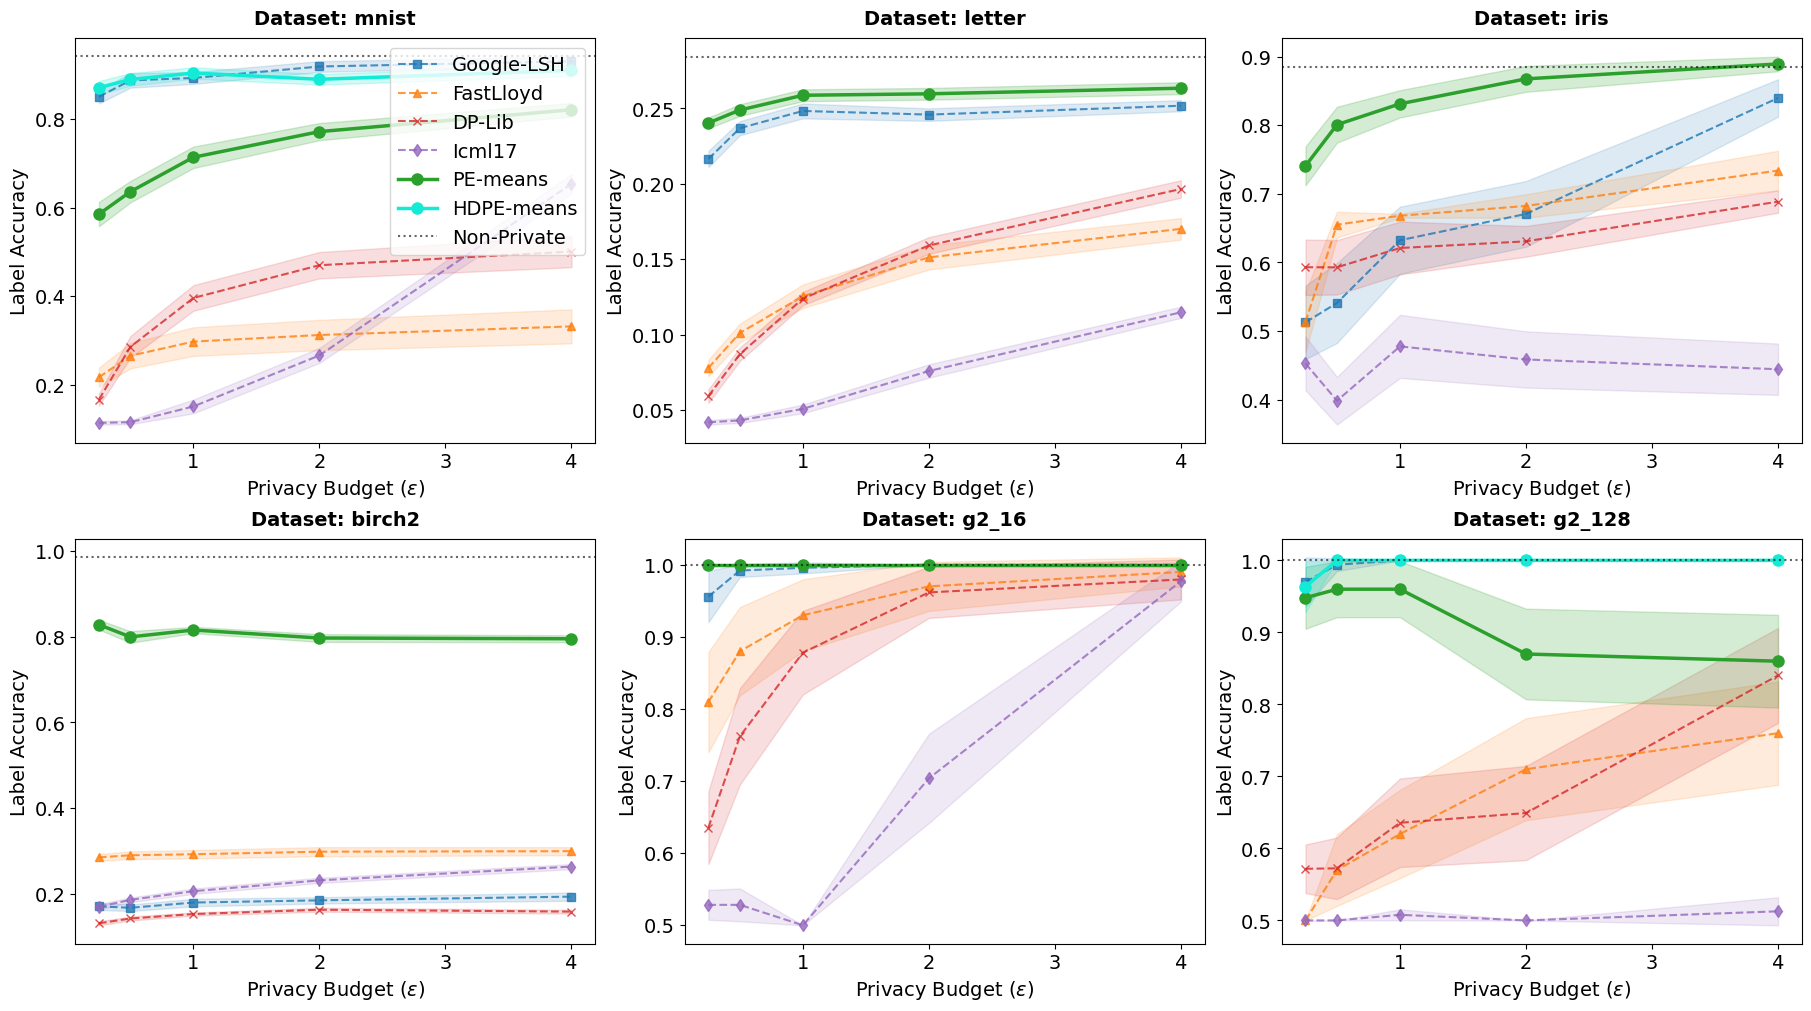

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats
import numpy as np
import pickle
from collections import defaultdict
import matplotlib as mpl
from matplotlib.lines import Line2D
from src.helpers import get_label_set, cluster_label_accuracy, EPSILONS

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

_, _, _, _, labels_dict = get_label_set()

LABEL_DATASET_NAMES = list(labels_dict.keys())

MAX_RUNS = 50

def mean_acc_ci(centers_list, data, labels):
    scores = [cluster_label_accuracy(data, labels, np.array(c))
              for c in centers_list[:MAX_RUNS]]
    valid = [s for s in scores if not np.isnan(s)]
    if len(valid) == 0:
        return np.nan, np.nan, np.nan
    if len(valid) == 1:
        return valid[0], valid[0], valid[0]
    m, se = np.mean(valid), scipy.stats.sem(valid)
    h = se * scipy.stats.t.ppf(0.975, len(valid) - 1)
    return m, m - h, m + h

n_cols = 3
n_rows = (len(LABEL_DATASET_NAMES) + n_cols - 1) // n_cols

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 14, 'axes.labelsize': 14,
    'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14,
})

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), constrained_layout=True)
axes = axes.flatten()

styles = {
    'PE':         {'color': '#2ca02c', 'marker': 'o', 'linewidth': 2.5, 'markersize': 8},
    'HDPE':       {'color': '#13ebd6', 'marker': 'o', 'linewidth': 2.5, 'markersize': 8},
    'Google-LSH': {'color': '#1f77b4', 'marker': 's', 'linestyle': '--', 'alpha': 0.8},
    'FastLloyd':  {'color': '#ff7f0e', 'marker': '^', 'linestyle': '--', 'alpha': 0.8},
    'DP-Lib':     {'color': '#d62728', 'marker': 'x', 'linestyle': '--', 'alpha': 0.8},
    'Icml17':     {'color': '#9467bd', 'marker': 'd', 'linestyle': '--', 'alpha': 0.8},
}

for i, dataset_name in enumerate(LABEL_DATASET_NAMES):
    ax = axes[i]
    # Use bounded datasets (same space the algorithms were run in)
    data   = datasets[dataset_name]
    labels = labels_dict[dataset_name]

    # --- Baselines ---
    baseline_paths = {
        'Google-LSH': f'{GOOGLE_FOLDER}/baseline_{dataset_name}.pkl',
        'FastLloyd':  f'{FASTLLOYD_FOLDER}/fastlloyd_{dataset_name}.pkl',
        'DP-Lib':     f'{DIFFPRIVLIB_FOLDER}/diffpriv_{dataset_name}.pkl',
        'Icml17':     f'{ICML_FOLDER}/baseline_{dataset_name}.pkl',
    }
    for algo, path in baseline_paths.items():
        try:
            with open(path, 'rb') as f:
                d = pickle.load(f)
            stats = [mean_acc_ci(d['centers'][str(e)], data, labels) for e in EPSILONS]
            m_vals, lb_vals, ub_vals = zip(*stats)
            ax.plot(EPSILONS, m_vals, label=algo, **styles[algo])
            ax.fill_between(EPSILONS, lb_vals, ub_vals, color=styles[algo]['color'], alpha=0.15)
        except Exception as e:
            print(f"  [{algo}] {dataset_name}: {e}")

    # --- PE (our method) ---
    try:
        with open(f'{PE_FOLDER}/grid_results_{dataset_name}.pkl', 'rb') as f:
            list_tuples = pickle.load(f)
        pe_centers = defaultdict(list)
        for config, _loss, centers, _conv in list_tuples:
            pe_centers[config['eps']].append(centers)
        stats = [mean_acc_ci(pe_centers[e], data, labels) if e in pe_centers
                 else (np.nan, np.nan, np.nan) for e in EPSILONS]
        m_pe, lb_pe, ub_pe = zip(*stats)
        ax.plot(EPSILONS, m_pe, label='PE-means', **styles['PE'])
        ax.fill_between(EPSILONS, lb_pe, ub_pe, color=styles['PE']['color'], alpha=0.2)
    except Exception as e:
        print(f"  [PE] {dataset_name}: {e}")

    # --- HDPE (only for high-dimensional datasets) ---
    if data.shape[1] > 32:
        try:
            with open(f'{HDPE_FOLDER}/grid_results_{dataset_name}.pkl', 'rb') as f:
                list_tuples = pickle.load(f)
            hdpe_centers = defaultdict(list)
            for config, _loss, centers, _conv in list_tuples:
                hdpe_centers[config['eps']].append(centers)
            stats = [mean_acc_ci(hdpe_centers[e], data, labels) if e in hdpe_centers
                     else (np.nan, np.nan, np.nan) for e in EPSILONS]
            m_hd, lb_hd, ub_hd = zip(*stats)
            ax.plot(EPSILONS, m_hd, label='HDPE-means', **styles['HDPE'])
            ax.fill_between(EPSILONS, lb_hd, ub_hd, color=styles['HDPE']['color'], alpha=0.2)
        except Exception as e:
            print(f"  [HDPE] {dataset_name}: {e}")

    # --- Non-private reference line ---
    try:
        with open(f'{GOOGLE_FOLDER}/baseline_{dataset_name}.pkl', 'rb') as f:
            d = pickle.load(f)
        np_val, _, _ = mean_acc_ci(d['centers']['inf'], data, labels)
        if not np.isnan(np_val):
            ax.axhline(np_val, color='black', linestyle=':', alpha=0.6, label='Non-Private')
    except Exception as e:
        print(f"  [non_private] {dataset_name}: {e}")

    ax.set_title(f"Dataset: {dataset_name}", fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel(r"Privacy Budget ($\epsilon$)")
    ax.set_ylabel("Label Accuracy")
    ax.grid(False)

legend_entries = [
    Line2D([0], [0], label='Google-LSH', **styles['Google-LSH']),
    Line2D([0], [0], label='FastLloyd',  **styles['FastLloyd']),
    Line2D([0], [0], label='DP-Lib',     **styles['DP-Lib']),
    Line2D([0], [0], label='Icml17',     **styles['Icml17']),
    Line2D([0], [0], label='PE-means',   **styles['PE']),
    Line2D([0], [0], label='HDPE-means', **styles['HDPE']),
    Line2D([0], [0], color='black', linestyle=':', label='Non-Private', alpha=0.6),
]
axes[0].legend(handles=legend_entries, loc='upper right', frameon=True)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.savefig('plots/label_accuracy.pdf', format='pdf', bbox_inches='tight', transparent=False)
plt.show()
plt.close()